In [15]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv('../../data/processed/combine_land_dataset_final_v1.csv')

In [17]:
# Show shape and info
print("Shape:", df.shape)
df.info()
df.describe(include='all')

Shape: (6659, 239)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6659 entries, 0 to 6658
Columns: 239 entries, address_subdivision to min_price_per_m2
dtypes: float64(10), int64(224), object(5)
memory usage: 12.1+ MB


,address_subdivision,address_locality,address_line_2,price_per_m2,land_area,price,longitude,latitude,near_Koh_Pich_in_km,Koh_Pich_nearest,...,f_trunk_link,f_unclassified,f_unused,geometry,population,h_id,mean_price_per_m2,max_price_per_m2,median_price_per_m2,min_price_per_m2
count,6659,6659,6659,6659.000000,6659.00000,6.659000e+03,6659.000000,6659.000000,6659.000000,6659.000000,...,6659.000000,6659.000000,6659.0,6659,6659.000000,6659,6659.000000,6659.000000,6659.000000,6659.000000
unique,1,12,110,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,4928,NaN,828,NaN,NaN,NaN,NaN
top,Phnom Penh,Pur SenChey,Phnom Penh Thmei,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,POINT (104.93 11.55),NaN,8865846ae9fffff,NaN,NaN,NaN,NaN
freq,6659,1166,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,192,NaN,211,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,1552.146895,547.84143,4.917235e+05,104.879192,11.553207,9.871002,0.001952,...,0.015318,0.066677,0.0,NaN,6285.681784,NaN,1552.146895,3116.923230,1483.022281,535.361579
std,NaN,NaN,NaN,1475.843543,9258.88039,4.376196e+06,0.064337,0.063241,6.172038,0.044144,...,0.122822,0.249480,0.0,NaN,8204.654181,NaN,1162.396732,2812.992716,1156.693437,625.416921
min,NaN,NaN,NaN,1.000000,1.00000,2.000000e+02,104.715138,11.412863,0.000000,0.000000,...,0.000000,0.000000,0.0,NaN,1.000000,NaN,80.656667,89.280000,84.490000,1.000000
25%,NaN,NaN,NaN,410.965000,87.00000,5.165015e+04,104.835755,11.511296,4.000000,0.000000,...,0.000000,0.000000,0.0,NaN,599.000000,NaN,503.341429,716.500000,438.595000,157.407407
50%,NaN,NaN,NaN,1132.750000,145.60000,1.500000e+05,104.891869,11.550000,9.000000,0.000000,...,0.000000,0.000000,0.0,NaN,2310.000000,NaN,1366.430000,2054.830000,1313.090000,295.000000
75%,NaN,NaN,NaN,2212.577669,212.00000,3.450000e+05,104.924368,11.589880,15.000000,0.000000,...,0.000000,0.000000,0.0,NaN,8223.000000,NaN,2308.651265,5319.148936,2098.404255,677.940000


In [18]:
df.isnull().sum()

address_subdivision    0
address_locality       0
address_line_2         0
price_per_m2           0
land_area              0
                      ..
h_id                   0
mean_price_per_m2      0
max_price_per_m2       0
median_price_per_m2    0
min_price_per_m2       0
Length: 239, dtype: int64

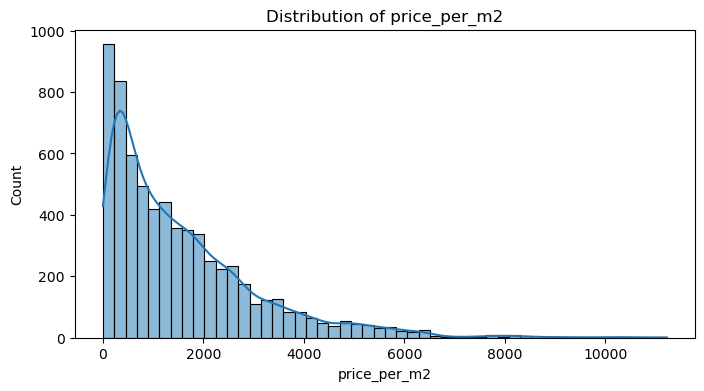

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(df['price_per_m2'], bins=50, kde=True)
plt.title('Distribution of price_per_m2')
plt.show()

In [20]:
from sklearn.preprocessing import LabelEncoder
df_encoded = df.copy()
# Apply Label Encoding to categorical columns
label_encoders = {}
for col in df_encoded.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le


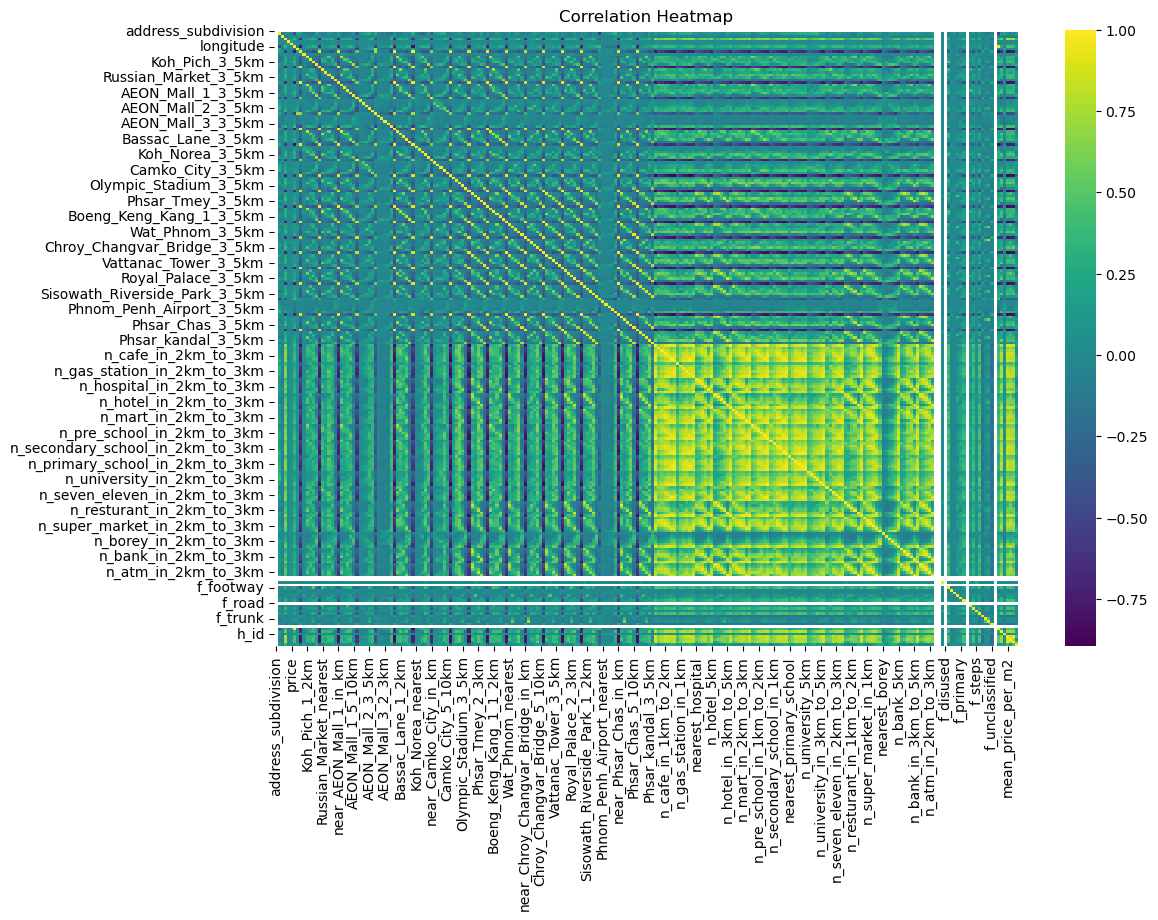

In [21]:
plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(), annot=False, cmap='viridis')
plt.title('Correlation Heatmap')
plt.show()

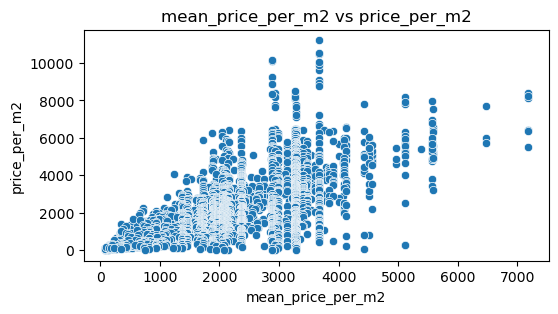

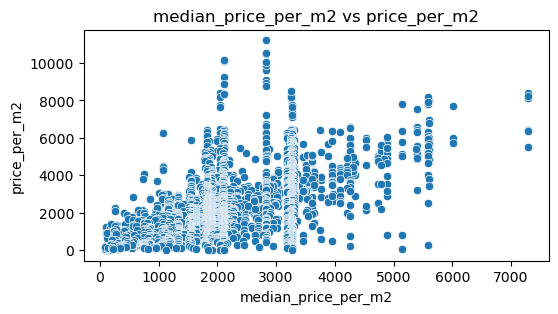

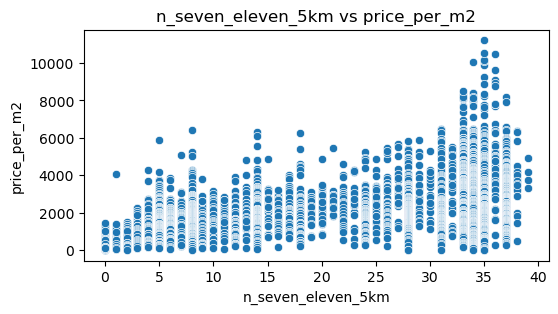

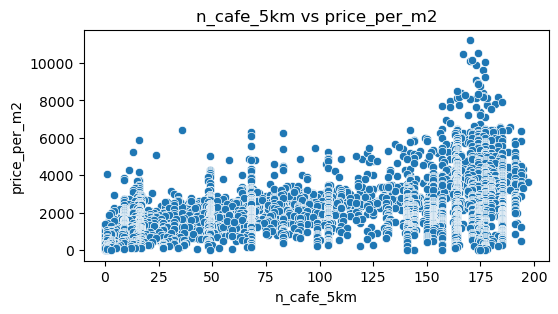

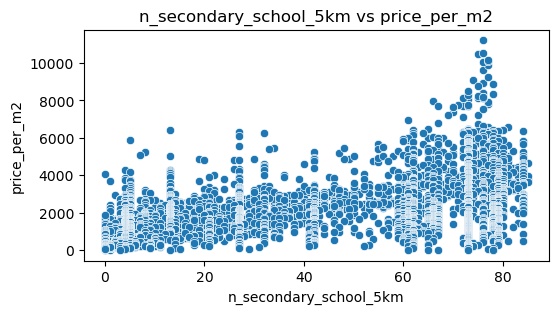

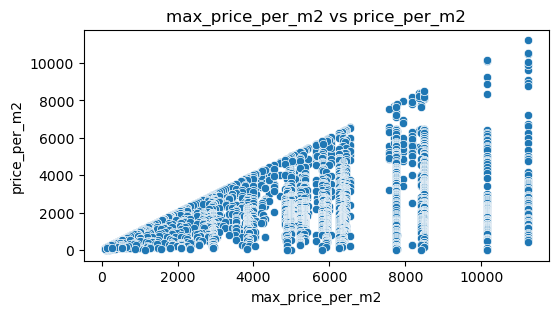

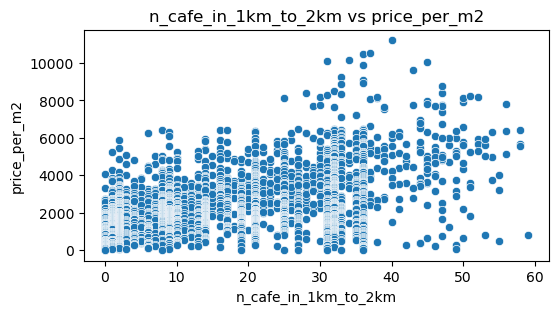

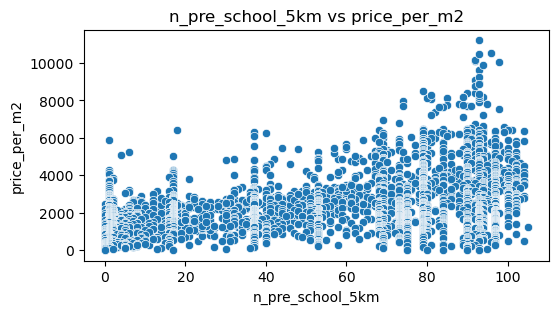

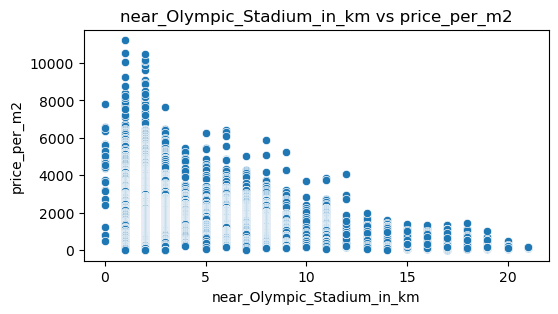

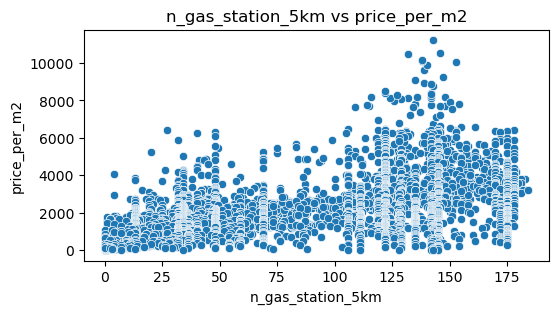

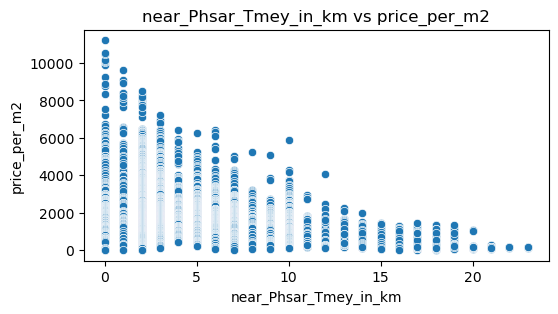

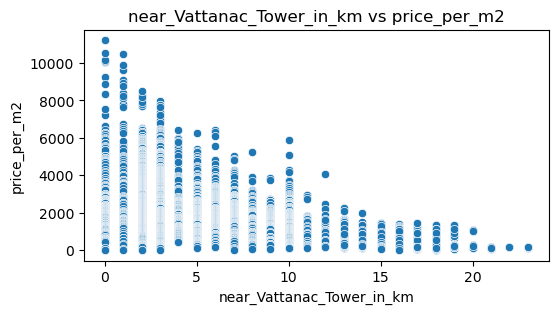

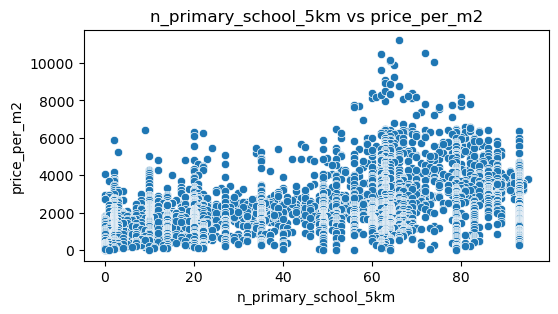

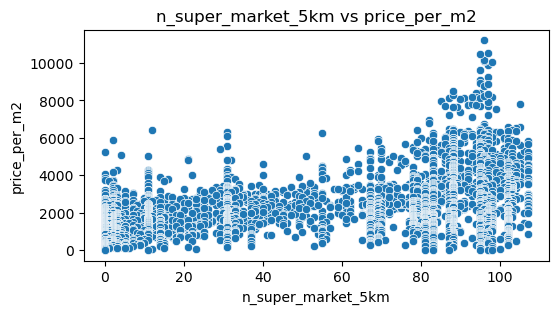

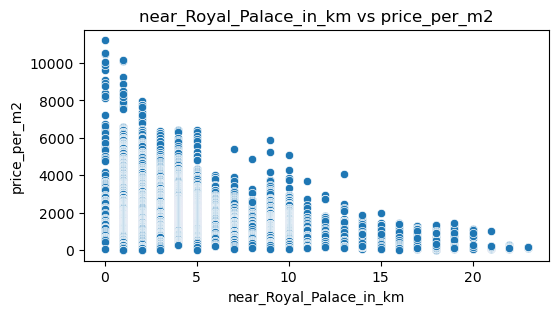

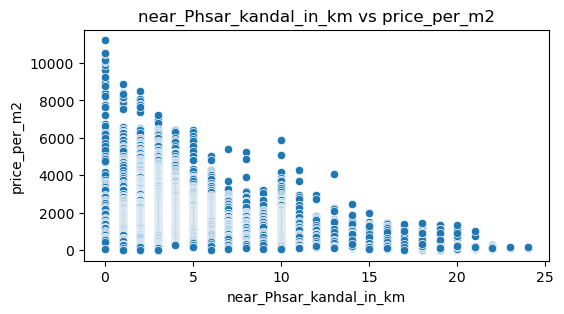

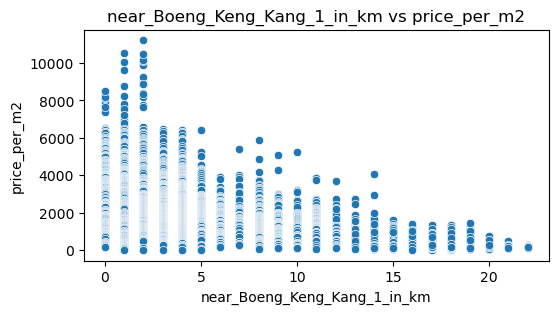

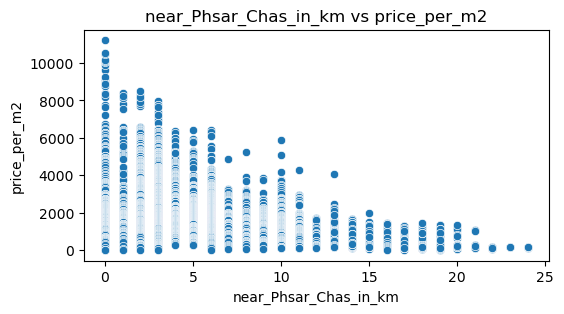

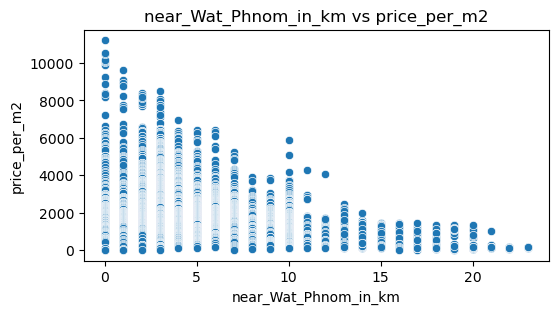

In [22]:
top_features = df_encoded.corr()['price_per_m2'].abs().sort_values(ascending=False)[1:20].index
for col in top_features:
    plt.figure(figsize=(6,3))
    sns.scatterplot(x=df_encoded[col], y=df_encoded['price_per_m2'])
    plt.title(f'{col} vs price_per_m2')
    plt.show()

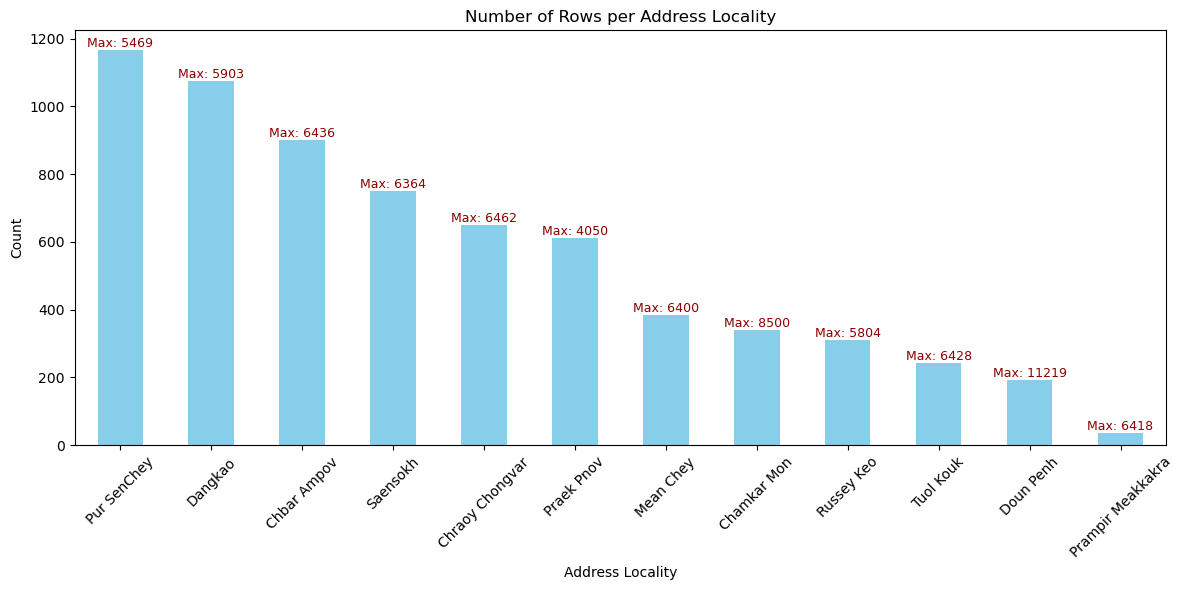

In [23]:
plt.figure(figsize=(12,6))
ax = df['address_locality'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Number of Rows per Address Locality')
plt.xlabel('Address Locality')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()

# Prepare a mapping from locality to max price_per_m2
max_price = df.groupby('address_locality')['price_per_m2'].max()

# Add max price_per_m2 labels on top of each bar
for p in ax.patches:
    locality = p.get_x() + p.get_width() / 2
    label = ax.get_xticklabels()[int(p.get_x() + p.get_width() / 2)].get_text()
    price = max_price[label]
    ax.annotate(f'Max: {price:.0f}', 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=9, color='darkred')

plt.show()

In [24]:
df

,address_subdivision,address_locality,address_line_2,price_per_m2,land_area,price,longitude,latitude,near_Koh_Pich_in_km,Koh_Pich_nearest,...,f_trunk_link,f_unclassified,f_unused,geometry,population,h_id,mean_price_per_m2,max_price_per_m2,median_price_per_m2,min_price_per_m2
0,Phnom Penh,Doun Penh,Chakto Mukh,5442.340000,200.0,1088468.00,104.958218,11.558388,1,0,...,0,0,0,POINT (104.958218177304 11.55838750186468),8.0,8865846a39fffff,4968.196667,5442.340000,4842.500000,4619.75
1,Phnom Penh,Doun Penh,Srah Chak,4226.760000,248.0,1048236.48,104.920556,11.584438,4,0,...,0,0,0,POINT (104.9205562206213 11.58443847258666),29835.0,8865846aa5fffff,3792.457000,4414.290000,3961.015000,2608.12
2,Phnom Penh,Chamkar Mon,Boeng Trabaek,3899.110000,72.0,280735.92,104.920474,11.539412,2,0,...,0,0,0,POINT (104.9204743117011 11.53941192849337),18375.0,8865846ac1fffff,2985.163696,6250.000000,3178.947368,93.75
3,Phnom Penh,Tuol Kouk,Tuek L'ak Ti Bei,3813.960000,76.0,289860.96,104.886224,11.558990,6,0,...,0,0,0,POINT (104.8862240095462 11.55899002091164),16116.0,8865846a95fffff,3456.074000,3813.960000,3458.420000,3193.30
4,Phnom Penh,Doun Penh,Srah Chak,3580.150000,234.0,837755.10,104.909105,11.589344,5,0,...,0,0,0,POINT (104.9091054452488 11.58934447384246),36545.0,8865846aa7fffff,3389.313104,5103.990000,3617.020000,1300.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6654,Phnom Penh,Saensokh,Phnom Penh Thmei,12.857143,1400.0,18000.00,104.920250,11.575610,3,0,...,0,0,0,POINT (104.92025 11.57561),16252.0,8865846aadfffff,2884.090269,10140.510000,2117.647059,1.00
6655,Phnom Penh,Chbar Ampov,Preaek Aeng,8.500000,400000.0,3400000.00,104.962474,11.522551,3,0,...,0,0,0,POINT (104.962474 11.522551),3342.0,8865846a51fffff,2075.961412,5000.000000,1900.000000,8.50
6656,Phnom Penh,Chraoy Chongvar,Chrouy Changvar,3.500000,10000.0,35000.00,104.925654,11.589674,4,0,...,1,0,0,POINT (104.925654 11.589674),11327.0,8865846819fffff,1951.915156,4888.888889,1843.750000,3.50
6657,Phnom Penh,Pur SenChey,Kamboul,1.000000,270000.0,270000.00,104.776086,11.531222,18,0,...,0,0,0,POINT (104.776086 11.5312221),1122.0,8865846e33fffff,756.053333,1147.410000,1119.750000,1.00


C:\Users\User\AppData\Local\Temp\ipykernel_25492\2506055262.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=grouped.head(20).values, y=grouped.head(20).index, palette="viridis")


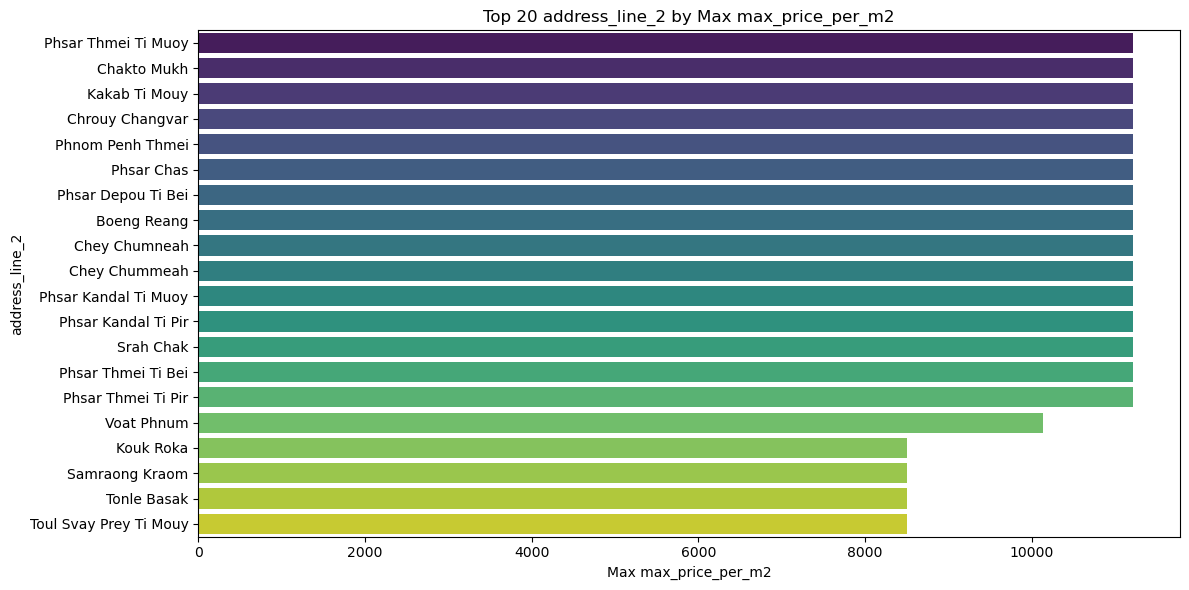

In [25]:
# Group by 'address_line_2' and get the max of 'h_id_price_max'
grouped = df.groupby('address_line_2')['max_price_per_m2'].max().sort_values(ascending=False)

# Plot the top 20 for visibility
plt.figure(figsize=(12, 6))
sns.barplot(x=grouped.head(20).values, y=grouped.head(20).index, palette="viridis")
plt.xlabel("Max max_price_per_m2")
plt.ylabel("address_line_2")
plt.title("Top 20 address_line_2 by Max max_price_per_m2")
plt.tight_layout()
plt.show()

In [26]:
kontur = gpd.read_file("D:\CADT\kontur_population_20231101.gpkg\population_clip_cambodia.gpkg", layer='population_clip_cambodia')

Total population in Cambodia (Kontur): 17,028,918


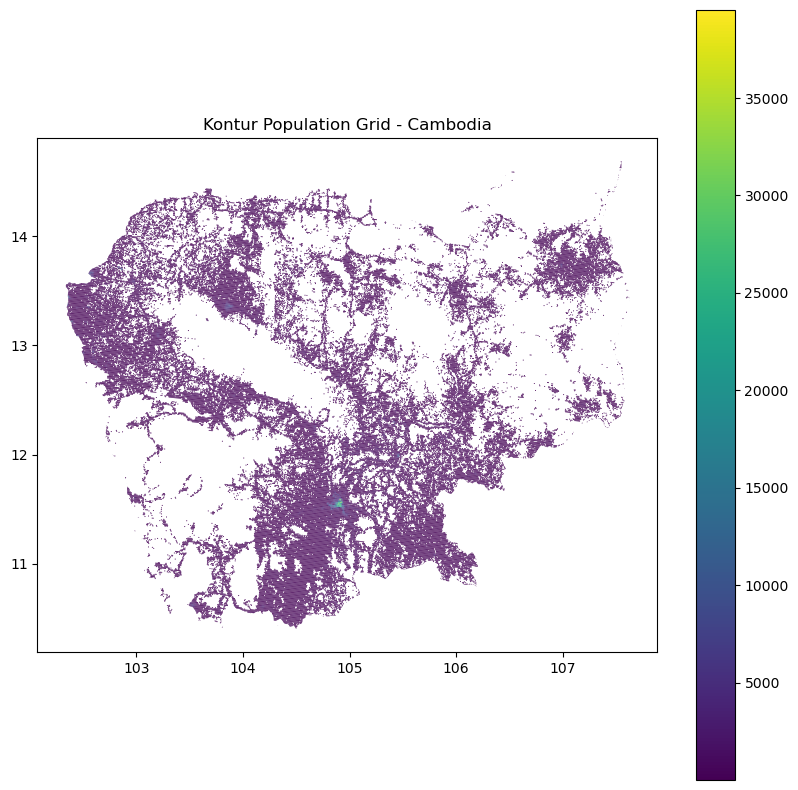

In [27]:
total_population = kontur['population'].sum()
print(f"Total population in Cambodia (Kontur): {total_population:,.0f}")
kontur.plot(column='population', cmap='viridis', legend=True, figsize=(10, 10))
plt.title('Kontur Population Grid - Cambodia')
plt.show()

In [28]:
communes = gpd.read_file(r'D:\CADT\kontur_population_20231101.gpkg\CambodiaCommune_Fixed.gpkg')

In [29]:
kontur.head()

,h3,population,geometry
0,886936db6dfffff,4.0,"MULTIPOLYGON (((107.35 13.782, 107.35 13.787, ..."
1,886936db67fffff,9.0,"MULTIPOLYGON (((107.36 13.773, 107.36 13.778, ..."
2,886936db65fffff,9.0,"MULTIPOLYGON (((107.35 13.774, 107.35 13.779, ..."
3,886936db63fffff,23.0,"MULTIPOLYGON (((107.37 13.78, 107.37 13.785, 1..."
4,886936db61fffff,9.0,"MULTIPOLYGON (((107.36 13.781, 107.36 13.786, ..."


In [30]:
phnom_penh_communes = communes[communes['ADM1_EN'].str.lower().str.contains('phnom penh')]
phnom_penh_communes.head()

,Shape_Leng,Shape_Area,ADM3_EN,ADM3_PCODE,ADM3_REF,ADM3ALT1EN,ADM3ALT2EN,ADM2_EN,ADM2_PCODE,ADM1_EN,ADM1_PCODE,ADM0_EN,ADM0_PCODE,date,validOn,geometry
67,0.194762,0.002058,Bak Kaeng,KH121005,None,None,None,Chraoy Chongvar,KH1210,Phnom Penh,KH12,Cambodia,KH,2014-10-14,2018-10-04,"MULTIPOLYGON (((104.96 11.712, 104.96 11.708, ..."
114,0.044324,0.000121,Boeng Kak Ti Muoy,KH120407,None,None,None,Tuol Kouk,KH1204,Phnom Penh,KH12,Cambodia,KH,2014-10-14,2018-10-04,"MULTIPOLYGON (((104.91 11.583, 104.91 11.58, 1..."
115,0.055176,0.000140,Boeng Kak Ti Pir,KH120408,None,None,None,Tuol Kouk,KH1204,Phnom Penh,KH12,Cambodia,KH,2014-10-14,2018-10-04,"MULTIPOLYGON (((104.9 11.578, 104.9 11.574, 10..."
118,0.030587,0.000062,Boeng Keng Kang Ti Bei,KH120104,None,None,None,Chamkar Mon,KH1201,Phnom Penh,KH12,Cambodia,KH,2014-10-14,2018-10-04,"MULTIPOLYGON (((104.92 11.544, 104.92 11.543, ..."
119,0.038194,0.000084,Boeng Keng Kang Ti Muoy,KH120102,None,None,None,Chamkar Mon,KH1201,Phnom Penh,KH12,Cambodia,KH,2014-10-14,2018-10-04,"MULTIPOLYGON (((104.92 11.544, 104.92 11.547, ..."


In [31]:
kontur = kontur.to_crs(phnom_penh_communes.crs)

In [32]:
kontur_pp = gpd.sjoin(kontur, phnom_penh_communes, how='inner', predicate='intersects')

In [33]:
df

,address_subdivision,address_locality,address_line_2,price_per_m2,land_area,price,longitude,latitude,near_Koh_Pich_in_km,Koh_Pich_nearest,...,f_trunk_link,f_unclassified,f_unused,geometry,population,h_id,mean_price_per_m2,max_price_per_m2,median_price_per_m2,min_price_per_m2
0,Phnom Penh,Doun Penh,Chakto Mukh,5442.340000,200.0,1088468.00,104.958218,11.558388,1,0,...,0,0,0,POINT (104.958218177304 11.55838750186468),8.0,8865846a39fffff,4968.196667,5442.340000,4842.500000,4619.75
1,Phnom Penh,Doun Penh,Srah Chak,4226.760000,248.0,1048236.48,104.920556,11.584438,4,0,...,0,0,0,POINT (104.9205562206213 11.58443847258666),29835.0,8865846aa5fffff,3792.457000,4414.290000,3961.015000,2608.12
2,Phnom Penh,Chamkar Mon,Boeng Trabaek,3899.110000,72.0,280735.92,104.920474,11.539412,2,0,...,0,0,0,POINT (104.9204743117011 11.53941192849337),18375.0,8865846ac1fffff,2985.163696,6250.000000,3178.947368,93.75
3,Phnom Penh,Tuol Kouk,Tuek L'ak Ti Bei,3813.960000,76.0,289860.96,104.886224,11.558990,6,0,...,0,0,0,POINT (104.8862240095462 11.55899002091164),16116.0,8865846a95fffff,3456.074000,3813.960000,3458.420000,3193.30
4,Phnom Penh,Doun Penh,Srah Chak,3580.150000,234.0,837755.10,104.909105,11.589344,5,0,...,0,0,0,POINT (104.9091054452488 11.58934447384246),36545.0,8865846aa7fffff,3389.313104,5103.990000,3617.020000,1300.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6654,Phnom Penh,Saensokh,Phnom Penh Thmei,12.857143,1400.0,18000.00,104.920250,11.575610,3,0,...,0,0,0,POINT (104.92025 11.57561),16252.0,8865846aadfffff,2884.090269,10140.510000,2117.647059,1.00
6655,Phnom Penh,Chbar Ampov,Preaek Aeng,8.500000,400000.0,3400000.00,104.962474,11.522551,3,0,...,0,0,0,POINT (104.962474 11.522551),3342.0,8865846a51fffff,2075.961412,5000.000000,1900.000000,8.50
6656,Phnom Penh,Chraoy Chongvar,Chrouy Changvar,3.500000,10000.0,35000.00,104.925654,11.589674,4,0,...,1,0,0,POINT (104.925654 11.589674),11327.0,8865846819fffff,1951.915156,4888.888889,1843.750000,3.50
6657,Phnom Penh,Pur SenChey,Kamboul,1.000000,270000.0,270000.00,104.776086,11.531222,18,0,...,0,0,0,POINT (104.776086 11.5312221),1122.0,8865846e33fffff,756.053333,1147.410000,1119.750000,1.00


In [34]:
kontur_pp.head()

,h3,population,geometry,index_right,Shape_Leng,Shape_Area,ADM3_EN,ADM3_PCODE,ADM3_REF,ADM3ALT1EN,ADM3ALT2EN,ADM2_EN,ADM2_PCODE,ADM1_EN,ADM1_PCODE,ADM0_EN,ADM0_PCODE,date,validOn
38862,886586a6ebfffff,255.0,"MULTIPOLYGON (((104.98 11.709, 104.98 11.714, ...",466,0.209855,0.001835,Kaoh Dach,KH121004,None,None,None,Chraoy Chongvar,KH1210,Phnom Penh,KH12,Cambodia,KH,2014-10-14,2018-10-04
38868,886586a6ddfffff,1337.0,"MULTIPOLYGON (((104.96 11.687, 104.96 11.692, ...",466,0.209855,0.001835,Kaoh Dach,KH121004,None,None,None,Chraoy Chongvar,KH1210,Phnom Penh,KH12,Cambodia,KH,2014-10-14,2018-10-04
38869,886586a6dbfffff,125.0,"MULTIPOLYGON (((104.95 11.681, 104.95 11.686, ...",466,0.209855,0.001835,Kaoh Dach,KH121004,None,None,None,Chraoy Chongvar,KH1210,Phnom Penh,KH12,Cambodia,KH,2014-10-14,2018-10-04
38870,886586a6d9fffff,764.0,"MULTIPOLYGON (((104.95 11.68, 104.95 11.685, 1...",466,0.209855,0.001835,Kaoh Dach,KH121004,None,None,None,Chraoy Chongvar,KH1210,Phnom Penh,KH12,Cambodia,KH,2014-10-14,2018-10-04
38871,886586a6d7fffff,323.0,"MULTIPOLYGON (((104.95 11.696, 104.95 11.701, ...",466,0.209855,0.001835,Kaoh Dach,KH121004,None,None,None,Chraoy Chongvar,KH1210,Phnom Penh,KH12,Cambodia,KH,2014-10-14,2018-10-04


In [35]:
kontur_pp.columns.tolist()

['h3',
 'population',
 'geometry',
 'index_right',
 'Shape_Leng',
 'Shape_Area',
 'ADM3_EN',
 'ADM3_PCODE',
 'ADM3_REF',
 'ADM3ALT1EN',
 'ADM3ALT2EN',
 'ADM2_EN',
 'ADM2_PCODE',
 'ADM1_EN',
 'ADM1_PCODE',
 'ADM0_EN',
 'ADM0_PCODE',
 'date',
 'validOn']

In [36]:
pp_population = kontur_pp.drop_duplicates(subset='h3', keep='first')

In [37]:
total_population = pp_population['population'].sum()
total_h3 = pp_population['h3'].count()

print(f"Total population in Phnom Penh (Kontur): {total_population:,.0f}")
print(f"Total population in Phnom Penh (Kontur): {total_h3}")

Total population in Phnom Penh (Kontur): 2,395,307
Total population in Phnom Penh (Kontur): 866


In [38]:
import folium

# Get the centroid of Phnom Penh for map center
center = phnom_penh_communes.geometry.unary_union.centroid
m = folium.Map(location=[center.y, center.x], zoom_start=12)

# Add hexagons
for _, row in kontur_pp.iterrows():
    geo_json = folium.GeoJson(row['geometry'], 
                              style_function=lambda x: {'fillColor': 'blue', 'color': 'blue', 'weight': 1, 'fillOpacity': 0.2})
    geo_json.add_to(m)

# Add boundary
folium.GeoJson(phnom_penh_communes.geometry.unary_union, 
               style_function=lambda x: {'color': 'red', 'weight': 2, 'fillOpacity': 0}).add_to(m)

m

C:\Users\User\AppData\Local\Temp\ipykernel_25492\2099173739.py:4: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  center = phnom_penh_communes.geometry.unary_union.centroid
C:\Users\User\AppData\Local\Temp\ipykernel_25492\2099173739.py:14: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  folium.GeoJson(phnom_penh_communes.geometry.unary_union,


In [39]:
grouping_columns = ['ADM1_EN', 'ADM2_EN', 'ADM3_EN', 'h3']  # Replace with actual column names

grouped_stats = kontur_pp[grouping_columns]

In [40]:
grouped_stats

,ADM1_EN,ADM2_EN,ADM3_EN,h3
38862,Phnom Penh,Chraoy Chongvar,Kaoh Dach,886586a6ebfffff
38868,Phnom Penh,Chraoy Chongvar,Kaoh Dach,886586a6ddfffff
38869,Phnom Penh,Chraoy Chongvar,Kaoh Dach,886586a6dbfffff
38870,Phnom Penh,Chraoy Chongvar,Kaoh Dach,886586a6d9fffff
38871,Phnom Penh,Chraoy Chongvar,Kaoh Dach,886586a6d7fffff
...,...,...,...,...
71625,Phnom Penh,Praek Pnov,Samraong,886580d047fffff
71627,Phnom Penh,Praek Pnov,Samraong,886580d043fffff
71628,Phnom Penh,Praek Pnov,Samraong,886580d041fffff
71640,Phnom Penh,Praek Pnov,Samraong,886580d00bfffff


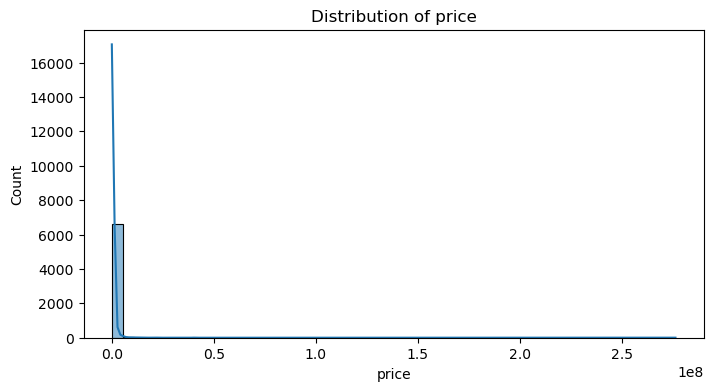

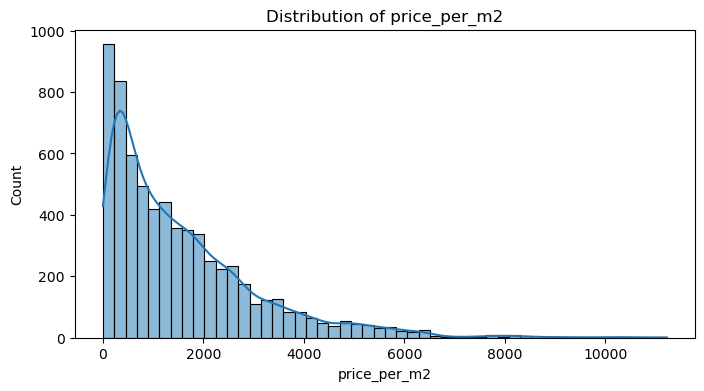

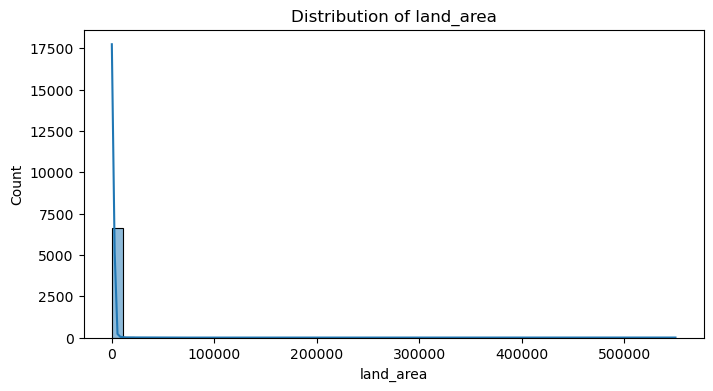

In [41]:
# 5. Visualize Distributions (Numerical)
num_cols = ['price', 'price_per_m2', 'land_area']
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, bins=50)
    plt.title(f'Distribution of {col}')
    plt.show()

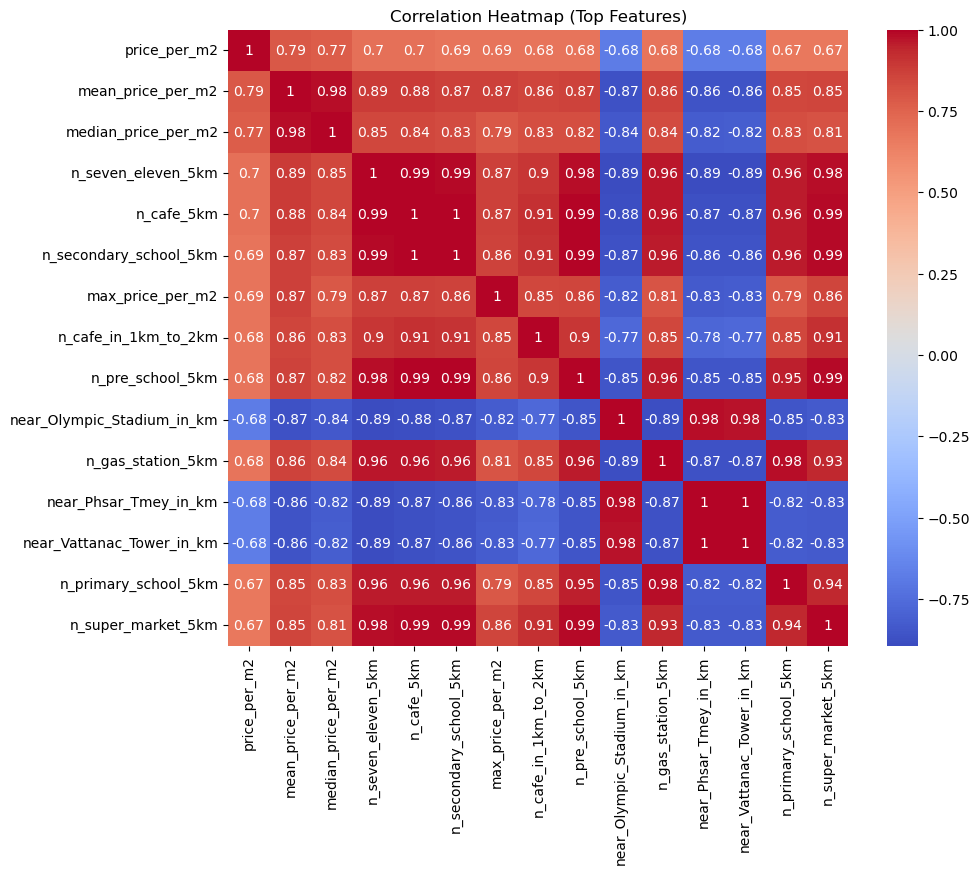

In [42]:
corr = df.corr(numeric_only=True)
top_corr = corr['price_per_m2'].abs().sort_values(ascending=False).head(15).index
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_corr].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Top Features)")
plt.show()

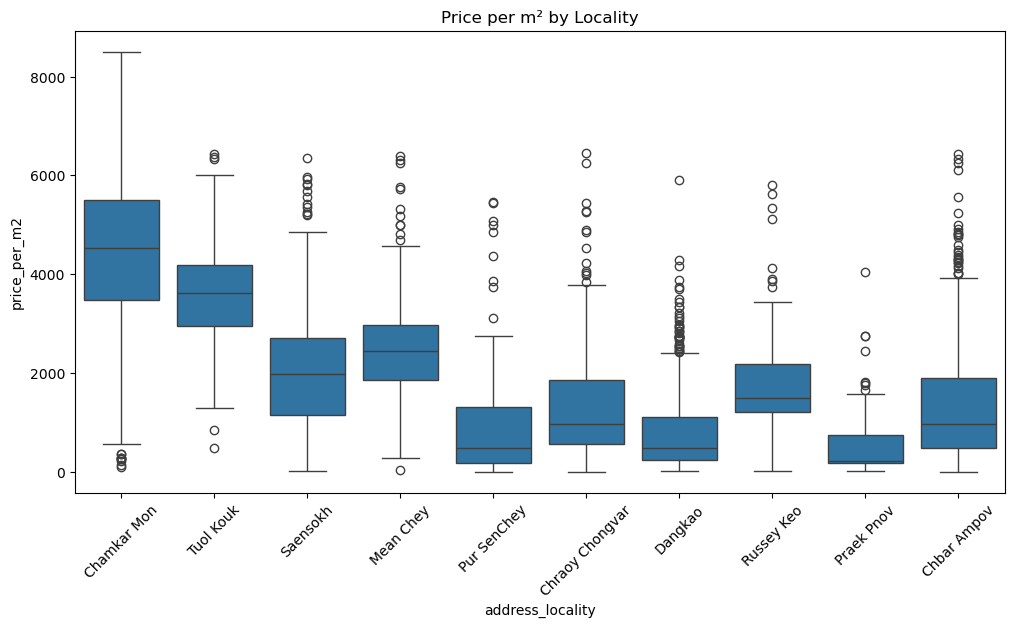

In [43]:
plt.figure(figsize=(12, 6))
top_locations = df['address_locality'].value_counts().head(10).index
sns.boxplot(x='address_locality', y='price_per_m2', data=df[df['address_locality'].isin(top_locations)])
plt.xticks(rotation=45)
plt.title("Price per m² by Locality")
plt.show()

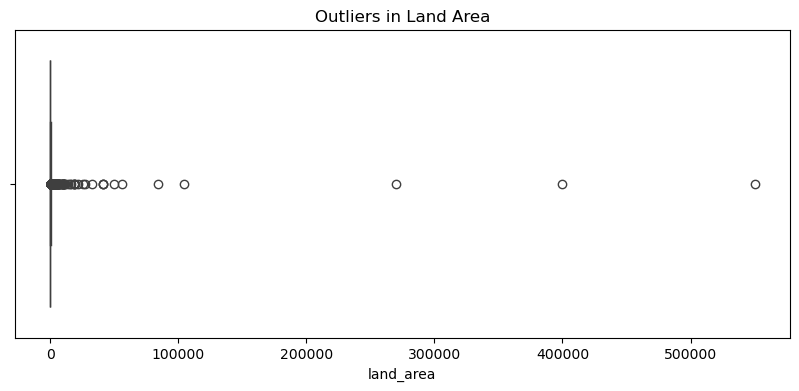

In [44]:
# 8. Outlier Detection (land_area)
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['land_area'])
plt.title("Outliers in Land Area")
plt.show()

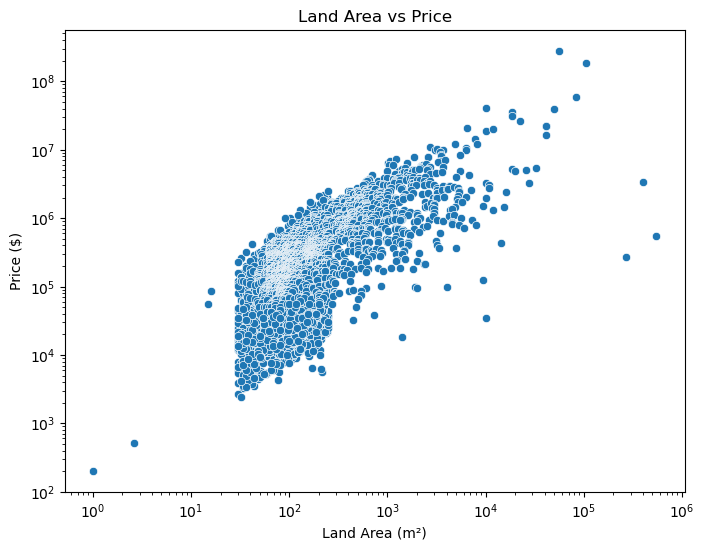

In [45]:

# 9. Scatter Plot (Area vs Price)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='land_area', y='price')
plt.title("Land Area vs Price")
plt.xlabel("Land Area (m²)")
plt.ylabel("Price ($)")
plt.xscale("log")
plt.yscale("log")
plt.show()

In [46]:
# import geopandas as gpd
# import simplekml

# def gdf_to_kml(gdf, output_file, name_col='h3', desc_col='population'):
#     """
#     Convert GeoDataFrame to KML with proper handling of MultiPolygons
#     :param gdf: GeoDataFrame with geometry
#     :param output_file: Output KML file path
#     :param name_col: Column to use for feature names
#     :param desc_col: Column to use for feature descriptions
#     """
#     kml = simplekml.Kml()
    
#     for idx, row in gdf.iterrows():
#         geom = row.geometry
        
#         # Skip empty or invalid geometries
#         if geom is None or geom.is_empty or not geom.is_valid:
#             continue
            
#         # Extract name and description
#         name = str(row[name_col])
#         desc = f"Population: {row[desc_col]}"
        
#         # Create a Placemark for each feature
#         placemark = kml.newfolder(name=name)  # Using newfolder to create a placemark
        
#         # Set description
#         placemark.description = desc
        
#         # Handle different geometry types
#         if geom.geom_type == 'MultiPolygon':
#             multigeom = placemark.newmultigeometry()
#             for poly in geom.geoms:
#                 kml_poly = multigeom.newpolygon()
#                 kml_poly.outerboundaryis = list(poly.exterior.coords)
#                 for interior in poly.interiors:
#                     kml_poly.newinnerboundary(coords=list(interior.coords))
                
#                 # Apply styling
#                 kml_poly.style.polystyle.color = simplekml.Color.changealphaint(150, 'FF00FF00')  # Green
#                 kml_poly.style.linestyle.width = 1.5
                
#         elif geom.geom_type == 'Polygon':
#             kml_poly = placemark.newpolygon()
#             kml_poly.outerboundaryis = list(geom.exterior.coords)
#             for interior in geom.interiors:
#                 kml_poly.newinnerboundary(coords=list(interior.coords))
                
#             # Apply styling
#             kml_poly.style.polystyle.color = simplekml.Color.changealphaint(150, 'FF00FF00')  # Green
#             kml_poly.style.linestyle.width = 1.5
            
#         else:
#             print(f"Skipping non-polygon geometry: {geom.geom_type}")
    
#     kml.save(output_file)
#     print(f"KML file saved to {output_file}")

# gdf_to_kml(
#     kontur_pp, 
#     output_file="h3_population.kml",
#     name_col='h3',
#     desc_col='population'
# )